In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
#no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

Loading in data

In [4]:
#establishing  metadata paths
#MC reps
yaml_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'/'wells.yaml'

#BAD reps
yaml_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate3.yaml'
yaml_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate4.yaml'
yaml_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate5.yaml'
yaml_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'6-wells.yaml'

In [5]:
#establishing single cell csv paths
#MC reps
data_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'
data_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'
data_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'

#BAD reps
data_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate3'
data_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate4'
data_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate5'
data_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_6-wells'

In [6]:
#loading data
#MC data
df_1_96 = rd.flow.load_csv_with_metadata(data_path_1_96, yaml_path_1_96)
df_2_96 = rd.flow.load_csv_with_metadata(data_path_2_96, yaml_path_2_96)
df_6 = rd.flow.load_csv_with_metadata(data_path_12_6, yaml_path_12_6)

#BAD data
df_plate3 = rd.flow.load_csv_with_metadata(data_path_plate3, yaml_path_plate3)
df_plate4 = rd.flow.load_csv_with_metadata(data_path_plate4, yaml_path_plate4)
df_plate5 = rd.flow.load_csv_with_metadata(data_path_plate5, yaml_path_plate5)
df_6wells = rd.flow.load_csv_with_metadata(data_path_6wells, yaml_path_6wells)

Compiling data

In [7]:
df = pd.concat([df_1_96, df_2_96, df_plate3, df_plate4, df_plate5, df_6wells, df_6], ignore_index=True)

#remove negative values for eGFP-A and eGFP-H, replace with 1
df.loc[df['eGFP-A'] <=0, 'eGFP-A'] = 1
df.loc[df['eGFP-H'] <=0, 'eGFP-H'] = 1
# Convert puro to int
df = df.astype({'puro_conc': 'int'})

In [8]:
figpath = "C:/Users/Grad2024/Downloads/"

visualizing GFP distributions for gating

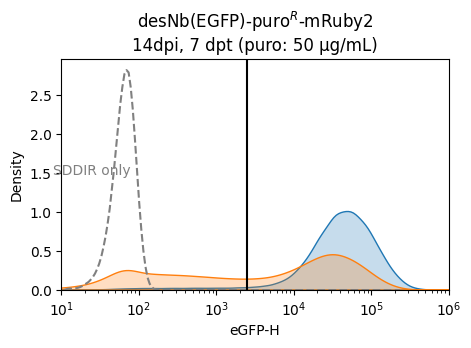

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2.5*10**3

# Plot eGFP-H
x = 'eGFP-H'

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 50)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)


# Plot 0 ug/mL ctrl
sns.kdeplot(data=df.loc[(df['retro-puro'] == 'SDDIR-only')],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('SDDIR only', (0.08, 0.5), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title('desNb(EGFP)-puro$^{R}$-mRuby2\n14dpi, 7 dpt (puro: 50 µg/mL)')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)


Creating summary dataframes

In [10]:
# Categorize iMNs based on eGFP_thresh
df['eGFP_cat'] = np.where(df['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib')

# Get total counts and percent of GFP-H+
group = ['retro-puro', 'puro_conc', 'biorep', 'scale']
count_df_reps = df.groupby([*group, 'well', 'eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')

# Get iMN yield per condition
data_iMN_count_reps = count_df_reps.reset_index(name='count')
data_total_count_reps = df.groupby([*group, 'well']).size().reset_index(name = 'total_count')

# Extract just the iMNs
data_iMN_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'iMN')]
data_iMN_count_reps = data_iMN_count_reps.loc[(data_iMN_count_reps['eGFP_cat'] == 'iMN')]

# Collapse to bio reps
# data_iMN_percent = data_iMN_percent_reps.groupby([*group]).mean().reset_index()
# data_iMN_count = data_iMN_count_reps.groupby([*group]).mean().reset_index()
data_iMN_percent = (
    data_iMN_percent_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_iMN_count = (
    data_iMN_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_total_count = (
    data_total_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\155295951.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Text(0.5, 0.98, '7 dpt (14 dpi), 96 well')

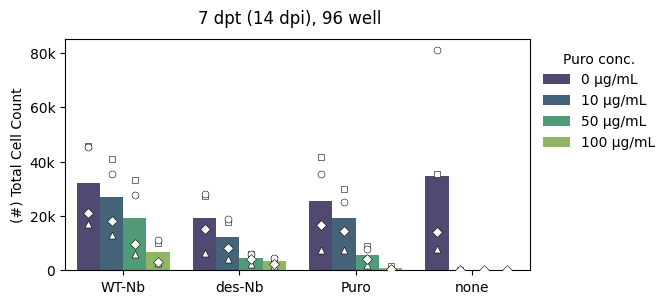

In [11]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
# General plotting params
x = 'retro-puro'
y = 'total_count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50, 100]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 4:'D'}
outline_colors = {1: 'black', 2: 'black', 3: 'black', 4:'black'}

# Plot
sns.barplot(
    ax=ax, data=data_total_count[data_total_count['scale'] == '96-well'],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=data_total_count[(data_total_count['biorep'] == rep) & (data_total_count['scale'] == '96-well')],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor=outline_colors[rep], linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total Cell Count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '50': '50 µg/mL',  '100': '100 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)




# Format
plt.suptitle('7 dpt (14 dpi), 96 well')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\1239725824.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\1239725824.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\1239725824.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])


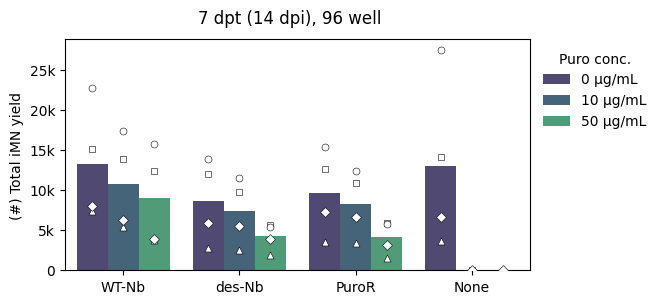

In [14]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
# General plotting params
x = 'retro-puro'
y = 'count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]


# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))
# Plot

sns.barplot(
    ax=ax, data=data_iMN_count[(data_iMN_count['scale'] == '96-well') & (data_iMN_count['puro_conc'] != 100)],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=data_iMN_count[(data_iMN_count['biorep'] == rep) & (data_iMN_count['scale'] == '96-well') & (data_iMN_count['puro_conc'] != 100)],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor=outline_colors[rep], linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total iMN yield')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '50': '50 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

label_map = {
    'WT-Nb': 'WT-Nb',
    'des-Nb': 'des-Nb',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])

# Format
plt.suptitle('7 dpt (14 dpi), 96 well')
# fig.tight_layout()  # Helps improve white spacing
plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\2497246098.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\2497246098.py:13: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(


des-Nb_0 vs. des-Nb_50: ****
2.1×
Puro_0 vs. Puro_50: ****
1.8×
WT-Nb_0 vs. WT-Nb_50: *
1.2×


C:\Users\Grad2024\AppData\Local\Temp\ipykernel_44924\2497246098.py:204: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])


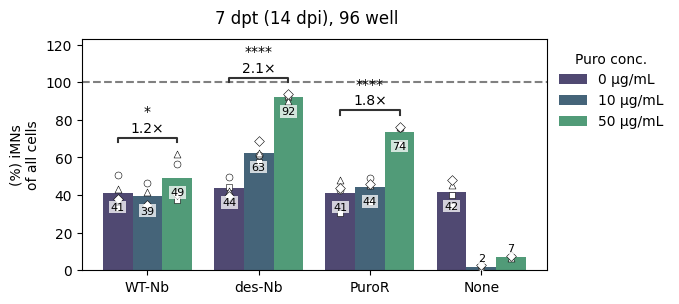

In [18]:
# General plotting params
x = 'retro-puro'
y = 'percent'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_percent[(data_iMN_percent['scale'] == '96-well') & (data_iMN_percent['puro_conc'] != 100)],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=data_iMN_percent[(data_iMN_percent['biorep'] == rep) & (data_iMN_percent['scale'] == '96-well')& (data_iMN_percent['puro_conc'] != 100)],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor=outline_colors[rep], linewidth=0.4,legend = False

    )
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '50': '50 µg/mL'}

handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

# # Add barplot labels
# for sub_ax in plt.gcf().get_axes():
#     for i in sub_ax.containers:
#         bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
#         for label in bar_labels:
#             label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

for container in ax.containers:
    labels = []
    for bar in container:
        h = bar.get_height()

        if h >= 15:
            y_text = h - 5
            va = "top"
        else:
            y_text = h + 2
            va = "bottom"

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y_text,
            f"{h:.0f}",
            ha="center",
            va=va,
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75, linewidth=0, pad=1)
        )

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50))
        

         ]


# annotator = Annotator(
#     plt.gca(),
#     pairs=pairs, order = order,
#     data= data_iMN_percent_reps[data_iMN_percent_reps['scale'] == '96-well'],
#     x=x,
#     y=y,
#     hue = hue
# )

# annotator.configure(test='t-test_ind', text_format='star', loc='inside')
# annotator.apply_and_annotate()

# subset = data_iMN_percent_reps[data_iMN_percent_reps['scale'] == '96-well']

# for (g1, h1), (g2, h2) in pairs:
#     m1 = subset.loc[
#         (subset[x] == g1) & (subset[hue] == h1), y
#     ].mean()

#     m2 = subset.loc[
#         (subset[x] == g2) & (subset[hue] == h2), y
#     ].mean()

#     fc = m2 / m1 if m1 > 0 else np.nan
#     print(f"{g2} vs {g1}: {fc:.2f}x")

# ax.text(
#     x_position,
#     y_position,
#     f"{fc:.1f}×",
#     ha="center",
#     fontsize=8
# )

from scipy.stats import ttest_ind
from statannotations.Annotator import Annotator

subset = data_iMN_percent_reps[(data_iMN_percent_reps['scale'] == '96-well') & (data_iMN_percent_reps['puro_conc'] != 100)]

# Build one annotation string for each pair
annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    # t-test
    _, p = ttest_ind(vals1, vals2)

    # convert p-value to stars
    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    # fold change (second group / first group)
    fc = vals2.mean() / vals1.mean()

    # annotation text
    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',   # use our custom text
    loc='inside',
    line_height=0.02,
    text_offset=2
)


annotator.set_custom_annotations(annotations)
annotator.annotate()
# Format

label_map = {
    'WT-Nb': 'WT-Nb',
    'des-Nb': 'des-Nb',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])

plt.suptitle('7 dpt (14 dpi), 96 well')
# fig.tight_layout()  # Helps improve white spacing
plt.savefig(figpath + 'bar_iMN-purity.svg', bbox_inches='tight')